## Why Do Some Models Perform Better?
## A Comparative Study of Logistic Regression, Random Forest and XGBoost for Classification

**Dataset:** UCI Student Performance (Social & Behavioral Features)  
**Target:** Will a student pass or fail their final exam? (Binary: 1 = Pass, 0 = Fail)  
**GitHub:** https://github.com/YOUR_USERNAME/student-performance-classifier  

---

## Aim
The aim of this tutorial is to compare three widely-used machine learning classification models:

- **Logistic Regression** — a linear probabilistic model
- **Random Forest** — an ensemble of decision trees (bagging)
- **XGBoost** — a gradient-boosted ensemble (boosting)

and to find out *why* they perform differently on the same dataset.

## Table of Contents
1. Introduction
2. Dataset
3. Exploratory Data Analysis (EDA)
4. Preprocessing & Train-Test Split
5. Model Setup — How Do These Models Think?
6. Training & Evaluation
7. ROC Curve Comparison
8. Feature Importance & Interpretability
9. Hyperparameter Tuning
10. Final Comparison & Conclusion
11. Ethical Considerations
12. References

## 1. Introduction

When solving a classification problem, one of the first decisions a data scientist needs to make is: *which model should I use?* Unfortunately, this is not always a straightforward decision. Different models make different assumptions about the data, and understanding these differences is key to making a good decision.

In this tutorial, we will use the UCI Student Performance dataset to examine this decision in a social context: **Can we predict whether a student will pass or fail based on their behavioural and social background?**

### The Three Models at a Glance

| Model | Core Idea | Type |
|---|---|---|
| **Logistic Regression** | Fits a linear boundary to log-odds of the outcome | Linear |
| **Random Forest** | Makes many decision trees and votes on the result | Ensemble (Bagging) |
| **XGBoost** | Makes many decision trees, one after another, each one trying to correct the previous one | Ensemble (Boosting) |

Each model has a different strength. By presenting them side by side on the same data, we will be able to see when and why one model performs better than another — and what this tells us about our data.

> **What this tutorial will help you answer:** Is it all about the number, or do different models give different insights about our data?

In [3]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import warnings
warnings.filterwarnings('ignore')

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (accuracy_score, confusion_matrix,
                              classification_report, roc_curve, auc)

# Colorblind-friendly palette (Wong 2011)
CB_BLUE   = '#0072B2'  # Logistic Regression
CB_ORANGE = '#D55E00'  # Random Forest
CB_GREEN  = '#009E73'  # XGBoost
COLORS    = [CB_BLUE, CB_ORANGE, CB_GREEN]

# Create figures directory if it doesn't exist
os.makedirs('figures', exist_ok=True)

print("All packages loaded successfully.")
print("figures/ directory ready.")


All packages loaded successfully.
figures/ directory ready.


## 2. Dataset

The **UCI Student Performance dataset** by Cortez & Silva (2008) will be used. It has records of 649 secondary school students. It has social, behavioral, and family background-related features. The features are:

- **Study time** - the number of hours spent studying per week
- **Past failures** - the number of classes the student has failed in the past
- **Weekend alcohol usage** - the amount of alcohol consumed by the student on weekends (scale - very low = 1 to very high = 5)
- **Going out frequency** - the frequency of going out for the student
- **Parental education** - the educational level of both mother and father
- **Absences** - the number of times the student has been absent from school

The **target variable** will be created based on the final grade of the student in the course. It will be defined as follows:

- `pass = 1` if `G3` > = 10
- `pass = 0` if `G3` < 10

This is a **binary classification** problem.

> **Source:** P. Cortez and A. Silva. "Using Data Mining to Predict Secondary School Student Performance." EUROSIS, 2008. Available at the [UCI Machine Learning Repository](https://archive.ics.uci.edu/dataset/320/student+performance).


In [5]:
df = pd.read_csv('student_data.csv')

print("Dataset shape:", df.shape)
print("\nPass/Fail distribution:")
print(df['pass'].value_counts().rename({1:'Pass (1)', 0:'Fail (0)'}))
print("\nFirst 5 rows:")
df.head()


Dataset shape: (649, 32)

Pass/Fail distribution:
pass
Pass (1)    362
Fail (0)    287
Name: count, dtype: int64

First 5 rows:


,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,romantic,famrel,freetime,goout,Dalc,Walc,health,absences,G3,pass
0,GP,F,17,U,LE3,T,4,2,other,services,...,yes,4,3,5,1,1,3,5,8,0
1,MS,F,18,U,GT3,T,4,2,services,other,...,no,5,5,3,1,5,5,3,11,1
2,GP,M,15,U,LE3,T,1,4,health,health,...,no,2,2,4,2,1,4,5,11,1
3,GP,M,20,U,LE3,T,4,0,services,other,...,no,5,3,4,4,2,4,3,14,1
4,GP,M,15,U,GT3,T,3,3,teacher,other,...,no,4,2,3,2,5,3,4,11,1


In [6]:
# Check for missing values
print("Missing values per column:")
print(df.isnull().sum().sum(), "total missing values")
print("\nBasic statistics for key numeric features:")
df[['age','studytime','failures','Walc','Dalc','absences','G3']].describe().round(2)


Missing values per column:
0 total missing values

Basic statistics for key numeric features:


,age,studytime,failures,Walc,Dalc,absences,G3
count,649.00,649.00,649.00,649.00,649.00,649.00,649.00
mean,17.20,2.24,0.47,2.29,1.82,4.97,9.64
std,1.69,0.94,0.79,1.29,1.09,2.12,3.15
min,15.00,1.00,0.00,1.00,1.00,0.00,0.00
25%,16.00,2.00,0.00,1.00,1.00,4.00,8.00
50%,17.00,2.00,0.00,2.00,1.00,5.00,10.00
75%,18.00,3.00,1.00,3.00,2.00,6.00,12.00
max,22.00,4.00,3.00,5.00,5.00,13.00,18.00


## 3. Exploratory Data Analysis (EDA)

It is important to understand the data before building models. We check the class distribution and also see how key behavioral features vary for students who have passed and those who have failed.

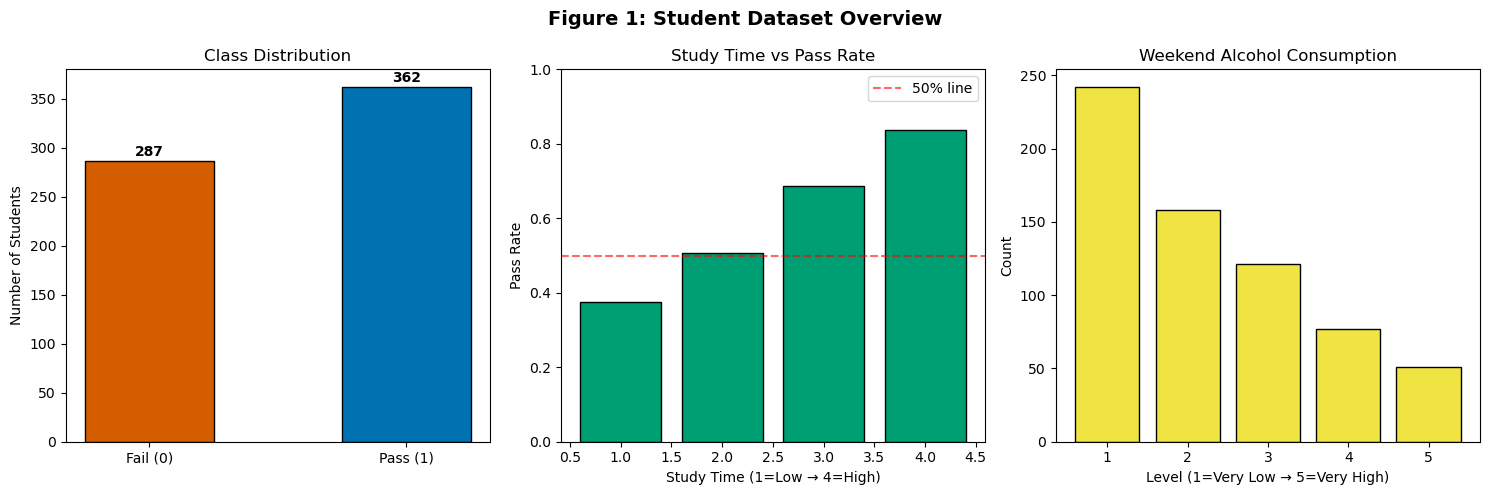

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle('Figure 1: Student Dataset Overview', fontsize=14, fontweight='bold')

# Class distribution
axes[0].bar(['Fail (0)', 'Pass (1)'], df['pass'].value_counts().sort_index(),
            color=[CB_ORANGE, CB_BLUE], edgecolor='k', width=0.5)
axes[0].set_title('Class Distribution')
axes[0].set_ylabel('Number of Students')
for i, v in enumerate(df['pass'].value_counts().sort_index()):
    axes[0].text(i, v+5, str(v), ha='center', fontweight='bold')

# Study time vs pass rate
studytime_pass = df.groupby('studytime')['pass'].mean()
axes[1].bar(studytime_pass.index, studytime_pass.values, color=CB_GREEN, edgecolor='k')
axes[1].set_title('Study Time vs Pass Rate')
axes[1].set_xlabel('Study Time (1=Low → 4=High)')
axes[1].set_ylabel('Pass Rate')
axes[1].set_ylim(0, 1)
axes[1].axhline(0.5, color='red', linestyle='--', alpha=0.6, label='50% line')
axes[1].legend()

# Weekend alcohol distribution
walc_counts = df['Walc'].value_counts().sort_index()
axes[2].bar(walc_counts.index, walc_counts.values, color='#F0E442', edgecolor='k')
axes[2].set_title('Weekend Alcohol Consumption')
axes[2].set_xlabel('Level (1=Very Low → 5=Very High)')
axes[2].set_ylabel('Count')

plt.tight_layout()
plt.savefig('figures/fig1_dataset_overview.png', bbox_inches='tight', dpi=150)
plt.show()


*Figure 1: Class distribution shows a slightly imbalanced dataset (362 pass, 287 fail). Higher study time is clearly associated with a higher pass rate.*

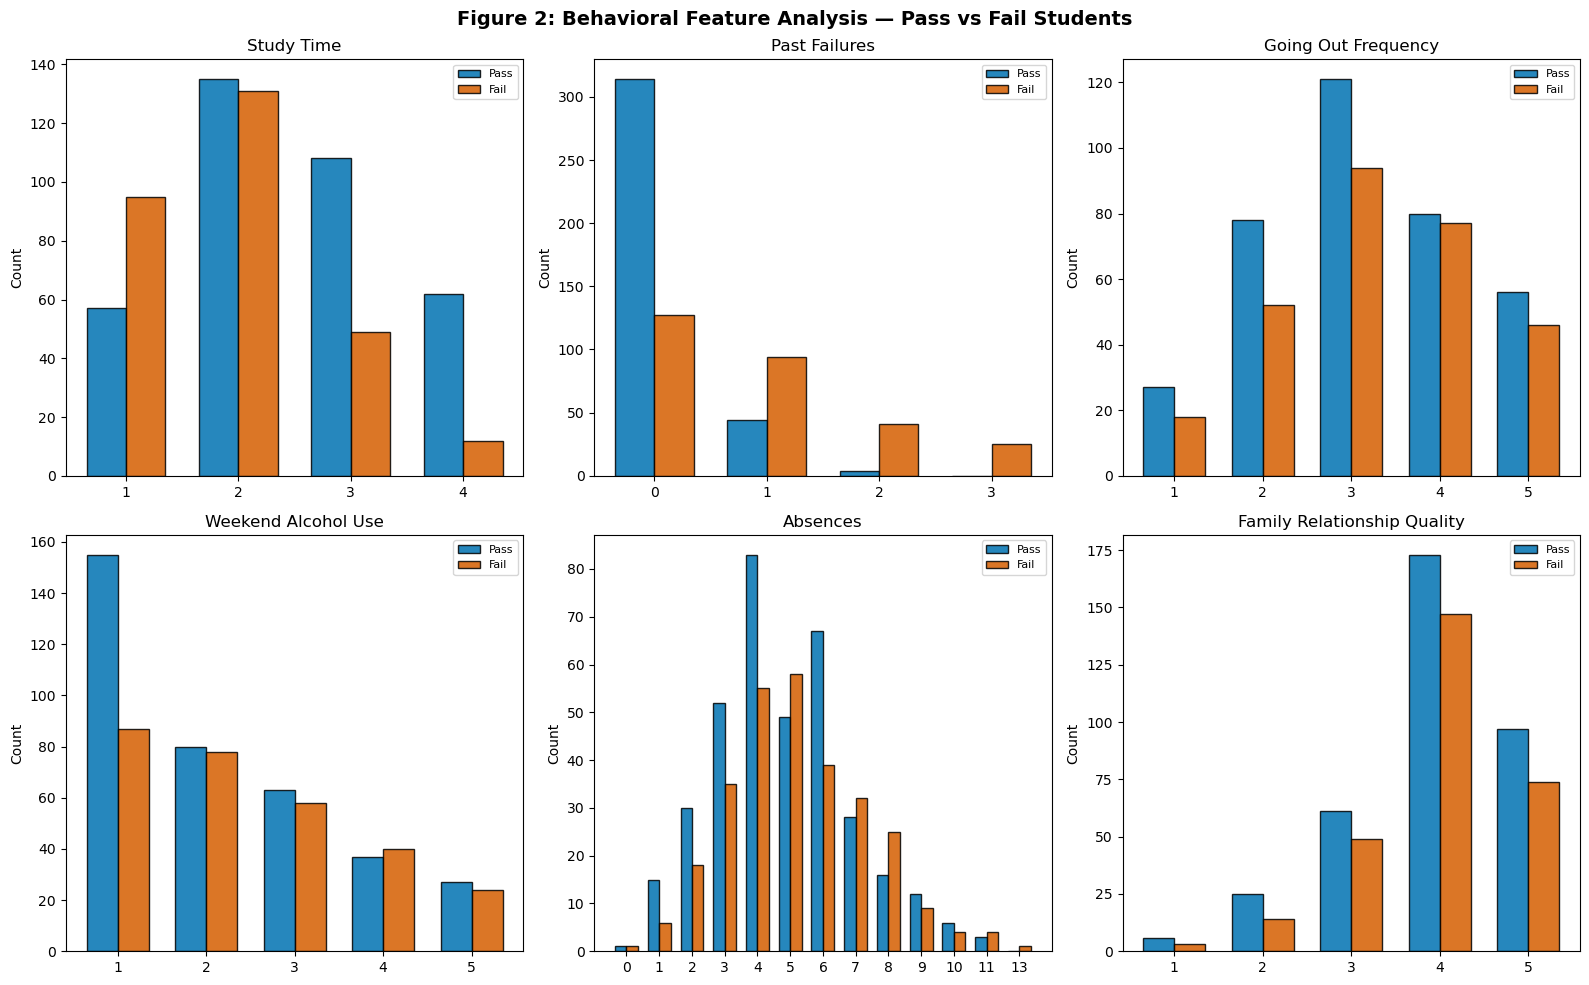

In [10]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle('Figure 2: Behavioral Feature Analysis — Pass vs Fail Students',
             fontsize=14, fontweight='bold')

features = ['studytime','failures','goout','Walc','absences','famrel']
titles   = ['Study Time','Past Failures','Going Out Frequency',
            'Weekend Alcohol Use','Absences','Family Relationship Quality']

for ax, feat, title in zip(axes.flat, features, titles):
    pass_v = df[df['pass']==1][feat]
    fail_v = df[df['pass']==0][feat]
    vals = sorted(df[feat].unique())
    x = np.arange(len(vals)); w = 0.35
    ax.bar(x-w/2, [len(pass_v[pass_v==v]) for v in vals], w,
           label='Pass', color=CB_BLUE, edgecolor='k', alpha=0.85)
    ax.bar(x+w/2, [len(fail_v[fail_v==v]) for v in vals], w,
           label='Fail', color=CB_ORANGE, edgecolor='k', alpha=0.85)
    ax.set_xticks(x); ax.set_xticklabels(vals)
    ax.set_title(title); ax.set_ylabel('Count'); ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig('figures/fig2_eda_features.png', bbox_inches='tight', dpi=150)
plt.show()


*Figure 2: Key patterns visible in the data:*
- *More past failures lead to a higher probability of failure*
- *More *study time* always helps to pass*
- *High *weekend alcohol use* and *going out* lead to failure*
- *Good *family relationships* help to pass slightly*

The patterns indicate that the data is likely to have some non-linear structure, which will impact the performance of each model.

## 4. Preprocessing & Train-Test Split

Since Logistic Regression only works on numeric features, we use `LabelEncoder` to convert categorical features like school, sex, and address into numeric features. Although this is not necessary for Tree-based models like Random Forest and XGBoost, it is easier to do so.

We remove the feature `G3`, which is the actual grade that our target feature `pass` is based on. This is because having this feature is too easy for any model and essentially provides a shortcut.

In [13]:
df_model = df.drop(columns=['G3'])  # Remove raw grade to avoid leakage

# Encode categorical features
le = LabelEncoder()
for col in df_model.select_dtypes(include='object').columns:
    df_model[col] = le.fit_transform(df_model[col])

X = df_model.drop(columns=['pass'])
y = df_model['pass']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

print(f"Training set: {X_train.shape[0]} samples")
print(f"Test set:     {X_test.shape[0]} samples")
print(f"Features:     {X.shape[1]}")
print(f"\nClass balance in test set:")
print(y_test.value_counts().rename({1:'Pass', 0:'Fail'}))


Training set: 454 samples
Test set:     195 samples
Features:     30

Class balance in test set:
pass
Pass    109
Fail     86
Name: count, dtype: int64


## 5. Model Setup — How Do These Models Think?

Before training, it is worth understanding the *conceptual difference* between these three models:

### Logistic Regression
Logistic regression tries to find a **linear boundary** in feature space. The probability to pass is given by:

$$P(\text{pass}=1) = \frac{1}{1 + e^{-(\beta_0 + \beta_1 x_1 + \ldots + \beta_n x_n)}}$$

### Random Forest (Bagging)
Random forest is a collection of decision trees, and each decision tree is trained on a **random subset** of the data and features. The final result is determined by **majority voting** across all decision trees.

### XGBoost (Boosting)
XGBoost is a collection of decision trees, and each decision tree is trained **sequentially**. Each decision tree tries to **correct** the mistakes made by previous trees. The final result is a **weighted sum** of all decision trees.

> **Key difference:** Random forest is a collection of decision trees trained **in parallel** and averaged together. XGBoost is a collection of decision trees trained **sequentially** and each tries to **correct** previous trees.

In [15]:
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Random Forest':       RandomForestClassifier(n_estimators=100, random_state=42),
    'XGBoost':             XGBClassifier(n_estimators=100, random_state=42,
                                         eval_metric='logloss', verbosity=0)
}

print("Models defined:")
for name, m in models.items():
    print(f"  - {name}: {type(m).__name__}")


Models defined:
  - Logistic Regression: LogisticRegression
  - Random Forest: RandomForestClassifier
  - XGBoost: XGBClassifier


## 6. Training & Evaluation

In [17]:
results = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]
    acc    = accuracy_score(y_test, y_pred)
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    roc_auc = auc(fpr, tpr)

    results[name] = {
        'model': model, 'y_pred': y_pred, 'y_prob': y_prob,
        'accuracy': acc, 'fpr': fpr, 'tpr': tpr, 'auc': roc_auc,
        'cm': confusion_matrix(y_test, y_pred)
    }

    print(f"\n{'='*45}")
    print(f"  {name}")
    print(f"{'='*45}")
    print(f"  Accuracy : {acc:.4f}")
    print(f"  AUC      : {roc_auc:.4f}")
    print("  Classification Report:")
    print(classification_report(y_test, y_pred, target_names=['Fail','Pass']))



  Logistic Regression
  Accuracy : 0.7538
  AUC      : 0.8412
  Classification Report:
              precision    recall  f1-score   support

        Fail       0.73      0.71      0.72        86
        Pass       0.77      0.79      0.78       109

    accuracy                           0.75       195
   macro avg       0.75      0.75      0.75       195
weighted avg       0.75      0.75      0.75       195


  Random Forest
  Accuracy : 0.7590
  AUC      : 0.8206
  Classification Report:
              precision    recall  f1-score   support

        Fail       0.76      0.66      0.71        86
        Pass       0.76      0.83      0.79       109

    accuracy                           0.76       195
   macro avg       0.76      0.75      0.75       195
weighted avg       0.76      0.76      0.76       195


  XGBoost
  Accuracy : 0.7385
  AUC      : 0.8013
  Classification Report:
              precision    recall  f1-score   support

        Fail       0.72      0.66      0.69  

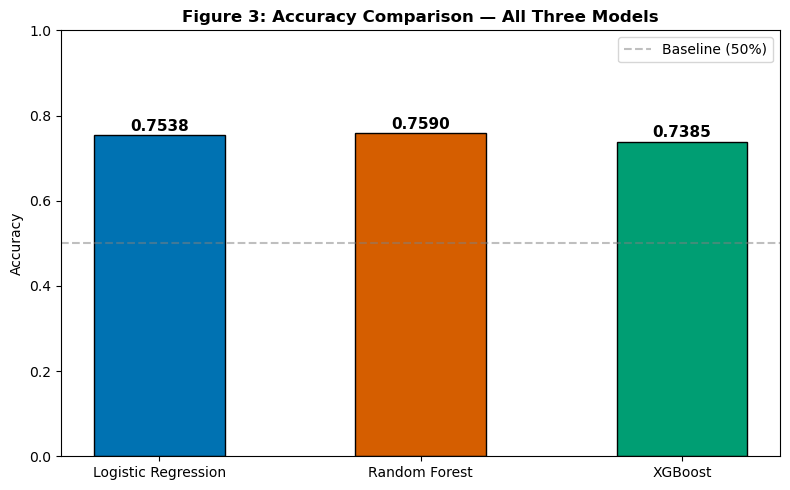

In [18]:
# Accuracy comparison bar chart
fig, ax = plt.subplots(figsize=(8, 5))
names = list(results.keys())
accs  = [results[n]['accuracy'] for n in names]
bars  = ax.bar(names, accs, color=COLORS, edgecolor='k', width=0.5)
ax.set_ylim(0, 1)
ax.set_ylabel('Accuracy')
ax.set_title('Figure 3: Accuracy Comparison — All Three Models', fontweight='bold')
for bar, acc in zip(bars, accs):
    ax.text(bar.get_x()+bar.get_width()/2, acc+0.01,
            f'{acc:.4f}', ha='center', fontweight='bold', fontsize=11)
ax.axhline(0.5, color='gray', linestyle='--', alpha=0.5, label='Baseline (50%)')
ax.legend()
plt.tight_layout()
plt.savefig('figures/fig3_accuracy_comparison.png', bbox_inches='tight', dpi=150)
plt.show()


*Figure 3: Accuracy is similar across all three models (~74–76%). This tells us that on this dataset, no single model dramatically outperforms the others in raw accuracy — but as we will see next, they differ in other important ways.*

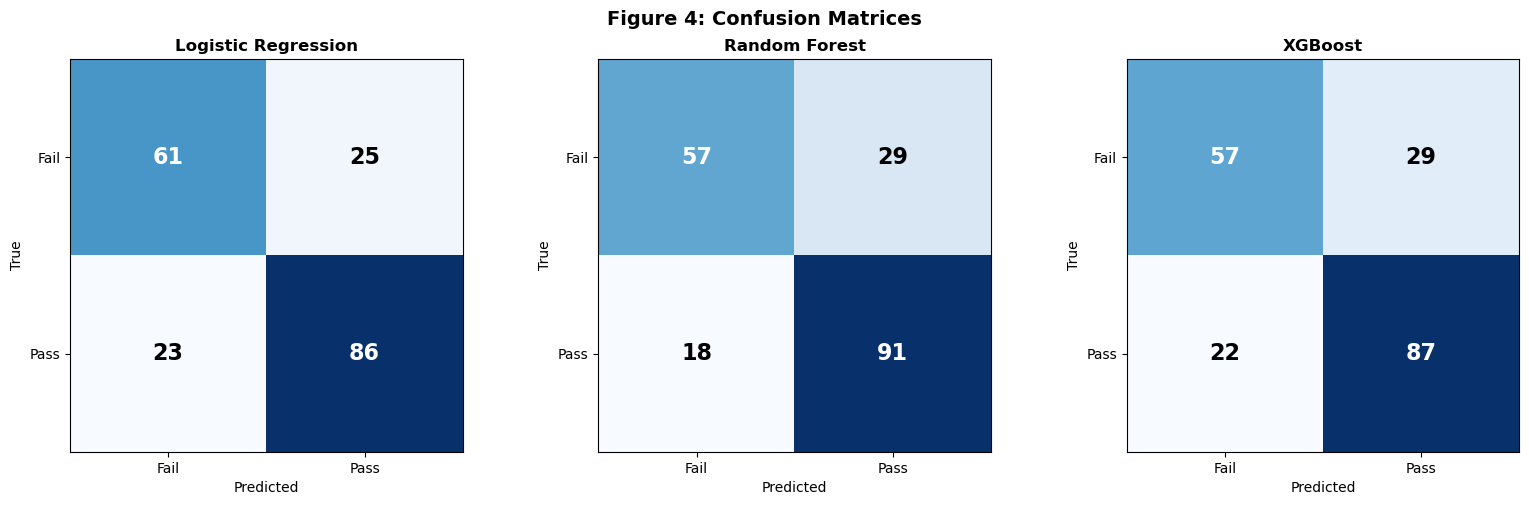

In [20]:
# Confusion matrices
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Figure 4: Confusion Matrices', fontsize=14, fontweight='bold')

for ax, (name, res) in zip(axes, results.items()):
    cm = res['cm']
    ax.imshow(cm, cmap='Blues')
    ax.set_xticks([0,1]); ax.set_yticks([0,1])
    ax.set_xticklabels(['Fail','Pass']); ax.set_yticklabels(['Fail','Pass'])
    ax.set_xlabel('Predicted'); ax.set_ylabel('True')
    ax.set_title(name, fontweight='bold')
    for i in range(2):
        for j in range(2):
            ax.text(j, i, str(cm[i,j]), ha='center', va='center', fontsize=16,
                    fontweight='bold', color='white' if cm[i,j]>cm.max()/2 else 'black')

plt.tight_layout()
plt.savefig('figures/fig4_confusion_matrices.png', bbox_inches='tight', dpi=150)
plt.show()


*Figure 4: The confusion matrices reveal that all three models tend to predict 'Pass' more often — reflecting the slight class imbalance. Look at how many Fail students each model misclassifies as Pass (top-right cell): this is the false-negative rate.*

## 7. ROC Curve Comparison

While accuracy is a good measure, it is not entirely reliable, especially when dealing with unbalanced classes. The **ROC curve** plots True Positive Rate against False Positive Rate at various classification threshold levels. **AUC** is a summary measure of this curve. An ideal model will have an **AUC** score of 1.0, and a random model will have a score of 0.5.

> ROC/AUC is especially useful here because it will show us how well our model **ranks** students based on failure risk, regardless of threshold.

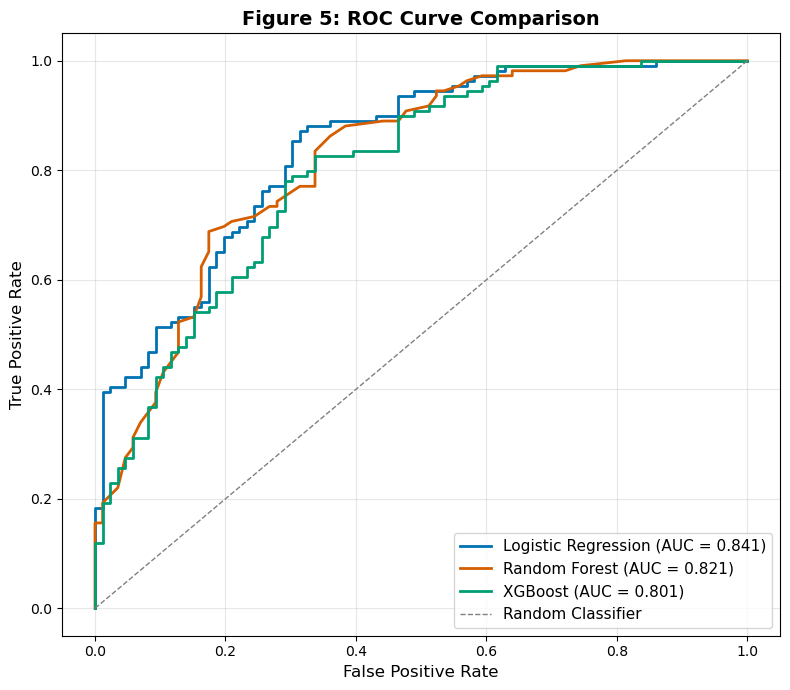

In [23]:
fig, ax = plt.subplots(figsize=(8, 7))

for (name, res), color in zip(results.items(), COLORS):
    ax.plot(res['fpr'], res['tpr'], color=color, lw=2,
            label=f"{name} (AUC = {res['auc']:.3f})")

ax.plot([0,1],[0,1], color='gray', linestyle='--', lw=1, label='Random Classifier')
ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate', fontsize=12)
ax.set_title('Figure 5: ROC Curve Comparison', fontsize=14, fontweight='bold')
ax.legend(loc='lower right', fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('figures/fig5_roc_curves.png', bbox_inches='tight', dpi=150)
plt.show()


*Figure 5: As shown, the highest AUC score of 0.841 is obtained by the Logistic Regression model, indicating that it is the best for **ranking** students based on the probability of passing, even though its accuracy is comparable to the other models.*

## 8. Feature Importance & Interpretability

One of the most significant differences between the two models is what they can teach us about the data. The Tree-based models (Random Forest & XGBoost) give us **feature importance**, or how much each feature was used to make the prediction. The Logistic Regression model gives us **coefficients**, or how much each feature contributes to the log-odds of passing.

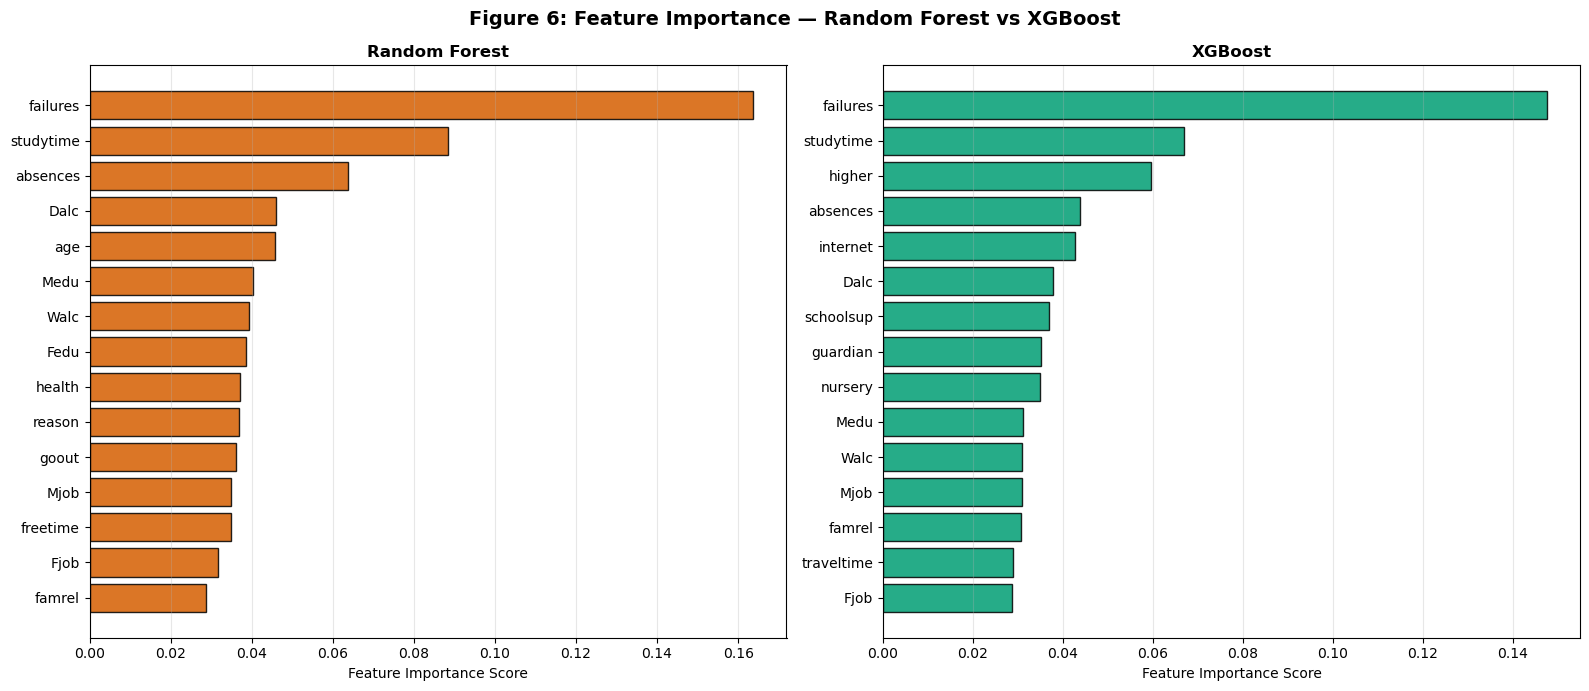

In [26]:
fig, axes = plt.subplots(1, 2, figsize=(16, 7))
fig.suptitle('Figure 6: Feature Importance — Random Forest vs XGBoost',
             fontsize=14, fontweight='bold')

for ax, name, color in zip(axes, ['Random Forest','XGBoost'], [CB_ORANGE, CB_GREEN]):
    imp = pd.Series(results[name]['model'].feature_importances_,
                    index=X.columns).sort_values(ascending=True).tail(15)
    ax.barh(imp.index, imp.values, color=color, edgecolor='k', alpha=0.85)
    ax.set_title(name, fontweight='bold', fontsize=12)
    ax.set_xlabel('Feature Importance Score')
    ax.grid(True, axis='x', alpha=0.3)

plt.tight_layout()
plt.savefig('figures/fig6_feature_importance.png', bbox_inches='tight', dpi=150)
plt.show()


*Figure 6: Both tree models agree that `failures` (past failures) and `absences` are the most important features. XGBoost places slightly more weight on alcohol use (`Walc`, `Dalc`) than Random Forest — reflecting its sensitivity to smaller patterns in the data.*

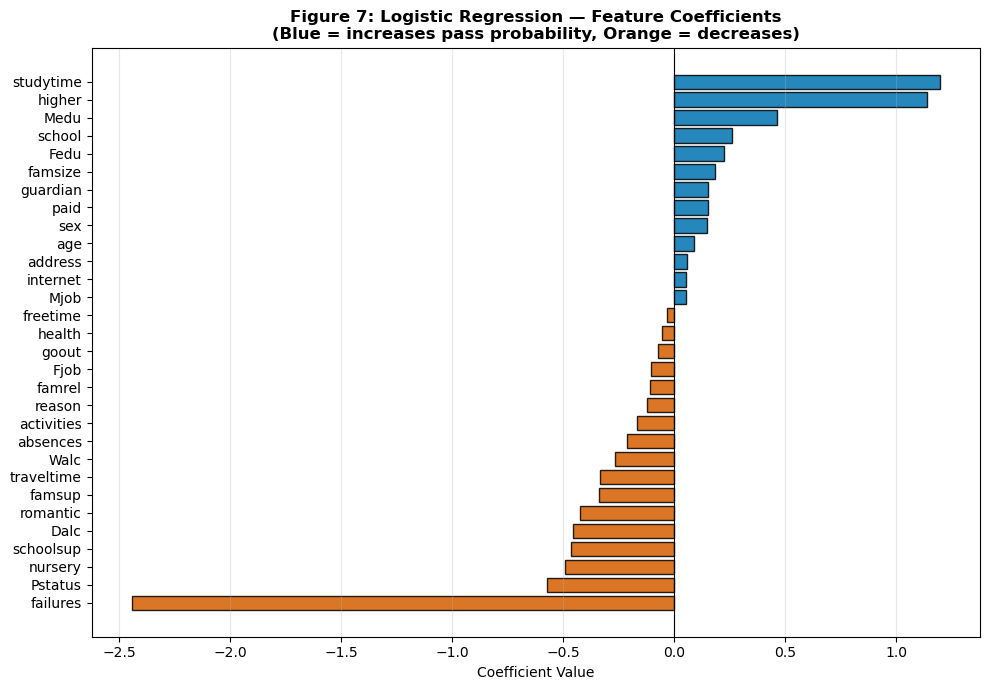

In [28]:
# Logistic Regression coefficients
coefs = pd.Series(results['Logistic Regression']['model'].coef_[0],
                  index=X.columns).sort_values()
colors_lr = [CB_ORANGE if c < 0 else CB_BLUE for c in coefs]

fig, ax = plt.subplots(figsize=(10, 7))
ax.barh(coefs.index, coefs.values, color=colors_lr, edgecolor='k', alpha=0.85)
ax.axvline(0, color='black', lw=0.8)
ax.set_title('Figure 7: Logistic Regression — Feature Coefficients\n'
             '(Blue = increases pass probability, Orange = decreases)',
             fontweight='bold')
ax.set_xlabel('Coefficient Value')
ax.grid(True, axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig('figures/fig7_lr_coefficients.png', bbox_inches='tight', dpi=150)
plt.show()


Figure 7: From the output of the Logistic Regression model, we can see that it provides us with **directional** insight. It means that features for which the coefficients are negative (in orange), like `failures`, `Walc`, and `goout`, will have a **decreasing effect** on the probability of passing. On the other hand, features for which the coefficients are positive (in blue), like `studytime` and `higher` (aspiration to pursue higher studies), will

## 9. Hyperparameter Tuning

The performance of the model relies on the hyperparameters used. We look at the following hyperparameters for the two models:

- **Random Forest Model: `n_estimators`** - the number of trees in the forest. The more trees, the better stability, but only to a certain degree.
- **XGBoost Model: `learning_rate`** - how much each tree contributes to the final prediction. Lower = slower learning, but more conservative; too high = overfitting.

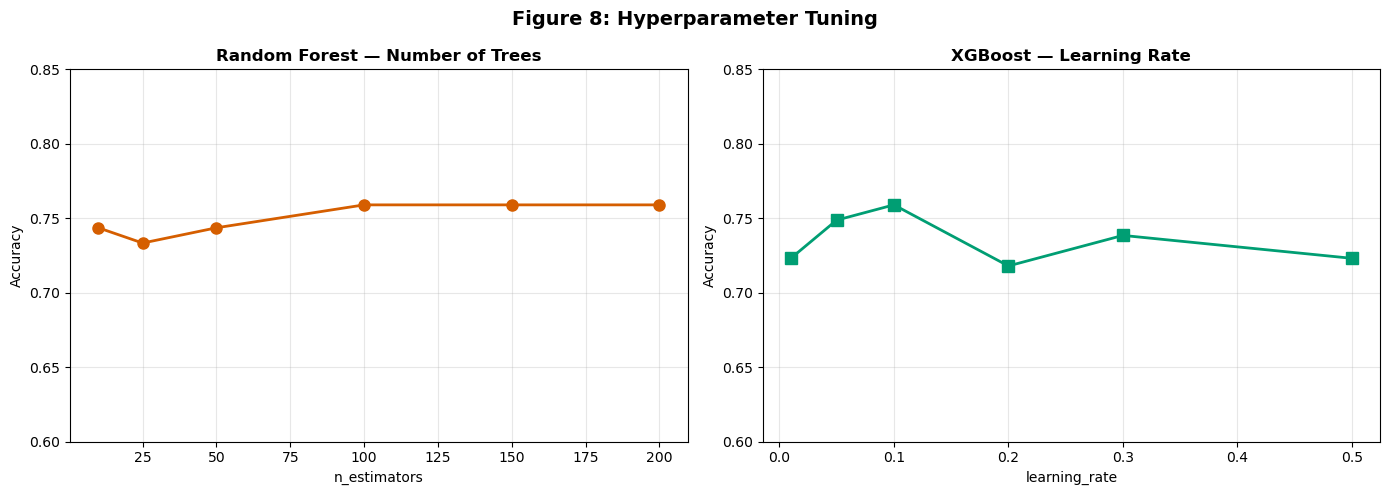

In [31]:
from sklearn.metrics import accuracy_score

n_estimators_vals = [10, 25, 50, 100, 150, 200]
rf_accs = []
for n in n_estimators_vals:
    m = RandomForestClassifier(n_estimators=n, random_state=42)
    m.fit(X_train, y_train)
    rf_accs.append(accuracy_score(y_test, m.predict(X_test)))

lr_vals = [0.01, 0.05, 0.1, 0.2, 0.3, 0.5]
xgb_accs = []
for lr in lr_vals:
    m = XGBClassifier(n_estimators=100, learning_rate=lr, random_state=42,
                      eval_metric='logloss', verbosity=0)
    m.fit(X_train, y_train)
    xgb_accs.append(accuracy_score(y_test, m.predict(X_test)))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Figure 8: Hyperparameter Tuning', fontsize=14, fontweight='bold')

axes[0].plot(n_estimators_vals, rf_accs, marker='o', color=CB_ORANGE, lw=2, markersize=8)
axes[0].set_title('Random Forest — Number of Trees', fontweight='bold')
axes[0].set_xlabel('n_estimators'); axes[0].set_ylabel('Accuracy')
axes[0].grid(True, alpha=0.3); axes[0].set_ylim(0.6, 0.85)

axes[1].plot(lr_vals, xgb_accs, marker='s', color=CB_GREEN, lw=2, markersize=8)
axes[1].set_title('XGBoost — Learning Rate', fontweight='bold')
axes[1].set_xlabel('learning_rate'); axes[1].set_ylabel('Accuracy')
axes[1].grid(True, alpha=0.3); axes[1].set_ylim(0.6, 0.85)

plt.tight_layout()
plt.savefig('figures/fig8_hyperparameter_tuning.png', bbox_inches='tight', dpi=150)
plt.show()


*Figure 8: Random Forest’s performance becomes stable very quickly, where the number of trees beyond 50 doesn’t contribute much. XGBoost’s learning rate also has an effect, where too high (0.5) makes the model unstable, but an optimal value (~0.1) is desired.*

## 10. Final Comparison & Conclusion

### Summary Table


In [34]:
summary = pd.DataFrame({
    'Model': list(results.keys()),
    'Accuracy': [f"{results[n]['accuracy']:.4f}" for n in results],
    'AUC':      [f"{results[n]['auc']:.4f}"      for n in results],
    'Interpretability': ['High (coefficients)', 'Medium (feature importance)', 'Medium (feature importance)'],
    'Training Speed':   ['Fast', 'Medium', 'Medium'],
    'Tuning Required':  ['Low', 'Low-Medium', 'High']
})

summary.style.set_properties(**{'text-align': 'left'}).hide(axis='index')


Model,Accuracy,AUC,Interpretability,Training Speed,Tuning Required
Logistic Regression,0.7538,0.8412,High (coefficients),Fast,Low
Random Forest,0.7590,0.8206,Medium (feature importance),Medium,Low-Medium
XGBoost,0.7385,0.8013,Medium (feature importance),Medium,High


### What Did We Learn?

This tutorial has demonstrated that **choosing a model is about more than accuracy**. Here is a quick recap of what we've learned:

1. **Logistic Regression** is competitive in terms of accuracy and dominates all other models in terms of AUC, making it the best model for *ranking* students based on risk. Moreover, it provides direct insight into which features matter most through its coefficients.

2. **Random Forest** is a safe choice. It performs well even without parameter tuning and provides useful feature importance scores, making it a great all-around choice.

3. **XGBoost** is a powerful tool, but for this problem, it doesn't significantly outperform other, simpler models. This may indicate that our data doesn't have complex structures that justify the added complexity of sequential boosting.

4. **The data is telling us a story.** In all three models, `failures`, `absences`, and `studytime` were consistently ranked among the top features. While this doesn't necessarily guarantee that these features matter, it suggests that they do, regardless of the model used.

## 11. Ethical Considerations

Ethical concerns associated with the task of predicting student performance include the following:

- **Reinforcing disadvantage:** The model might predict a student to fail based on certain characteristics, like parental education level or family background, and then allocate resources accordingly, which might only exacerbate the problem.
- **Labeling effects:** Students who are identified as "likely to fail" might experience a self-fulfilling prophecy.
- **Proxy discrimination:** The model might use certain characteristics, like parental job status (`Mjob` or `Fjob`) or home location (`address`), which might act as a proxy for socioeconomic status.
- **Data consent:** The data of the students is sensitive, and the model must comply with data protection regulations, like the GDPR, and obtain informed consent.

The purpose of a model like this should be to provide support to the students, not to label or disadvantage them in any manner. Such a model, like the Logistic Regression model, can be very useful as the results can be interpreted and challenged by the teachers involved.

> The above ethical concerns are in line with the EU AI Act, which classifies educational AI systems as **high-risk**, requiring human oversight, transparency, and bias auditing.

## 12. References

1. Cortez, P., & Silva, A. (2008). *Using Data Mining to Predict Secondary School Student Performance.* EUROSIS. Available at: https://archive.ics.uci.edu/dataset/320/student+performance

2. Breiman, L. (2001). *Random Forests.* Machine Learning, 45(1), 5–32. https://doi.org/10.1023/A:1010933404324

3. Chen, T., & Guestrin, C. (2016). *XGBoost: A Scalable Tree Boosting System.* Proceedings of the 22nd ACM SIGKDD International Conference on Knowledge Discovery and Data Mining. https://doi.org/10.1145/2939672.2939785

4. Hosmer, D. W., Lemeshow, S., & Sturdivant, R. X. (2013). *Applied Logistic Regression* (3rd ed.). Wiley.

5. Wong, B. (2011). *Color blindness.* Nature Methods, 8(6), 441. https://doi.org/10.1038/nmeth.1618

6. Pedregosa, F. et al. (2011). *Scikit-learn: Machine Learning in Python.* Journal of Machine Learning Research, 12, 2825–2830.

7. European Commission (2021). *Proposal for a Regulation on Artificial Intelligence (AI Act).* https://eur-lex.europa.eu/legal-content/EN/TXT/?uri=CELEX:52021PC0206
